# 31 — `cartogram`

A choropleth colours a region but leaves its size alone, so a small region with a huge value is easy to miss and
a vast empty one dominates the page. `Map.cartogram` attacks that directly: it **scales each polygon about its
own centroid** in proportion to a value, so the thing being measured controls the ink.

By the end you will be able to build a cartogram from a polygon collection, pair the scaling with a colour, and
control how extreme the distortion gets.

API: [`Map.cartogram`](../../reference/static_map.md).

> **Where this data comes from.** Everything in this notebook is real, downloaded with
> [earthlens](https://github.com/serapeum-org/earthlens) and committed under `examples/data/`.
> `examples/data/ATTRIBUTION.md` records each source and its licence.


**Setup** — plus the pyramids `Dataset` reader, for the population raster.

In [1]:
%matplotlib inline
from pathlib import Path

import matplotlib.pyplot as plt
from pyramids.feature import FeatureCollection

from digitalearth.static import Map

# The notebook's own folder is the kernel's working directory, so the bundled
# example data sits three levels up: docs/examples/plots -> repo root.
DATA = Path("../../../examples/data")

# UTM zone 32N: a metric CRS, correct for south-west Germany. Distance-based
# renders (Voronoi, hex lattices, kernels) must not be computed in degrees.
UTM32 = 25832

from pyramids.dataset import Dataset


## The data

Germany's 16 federal states (**geoBoundaries** ADM1), and the **WorldPop** 1 km population grid for 2020. The
states carry no measurement of their own, so the population comes from the raster.

In [2]:
states = FeatureCollection.read_file(str(DATA / "germany_adm1.geojson"))
pop = Dataset.read_file(str(DATA / "germany_pop_2020_1km.tif"))
print(f"{len(states)} states (EPSG:{states.crs.to_epsg()})")
print(f"population raster {pop.rows}x{pop.columns} cells, EPSG:{pop.epsg}")

16 states (EPSG:4326)
population raster 934x1100 cells, EPSG:4326


## Giving each polygon a value

A cartogram needs one number per polygon. `Dataset.zonal_stats` sums the population grid inside each state —
real GIS, done by pyramids, which is where that work belongs.

In [3]:
totals = pop.zonal_stats(states.to_crs(pop.epsg), stats=["sum"])
states = FeatureCollection(states.assign(
    population=(totals["sum"].to_numpy() / 1e6).round(2)
))
states[["shapeName", "population"]].sort_values("population", ascending=False).head(8)

,shapeName,population
9,Nordrhein-Westfalen,17.04
1,Bayern,12.50
0,Baden-Württemberg,10.30
8,Niedersachsen,7.58
6,Hessen,5.91
10,Rheinland-Pfalz,3.97
12,Sachsen,3.75
2,Berlin,3.23


Those are millions of people, and they are about right: North Rhine-Westphalia and Bavaria lead, the city-states
of Bremen and Hamburg trail. A ten-to-one spread between the largest and smallest is exactly the case where a
cartogram says more than a colour ramp.

## The baseline: a choropleth

Start undistorted, so the cartogram has something to be read against. Here the geography is true and only the
colour varies.

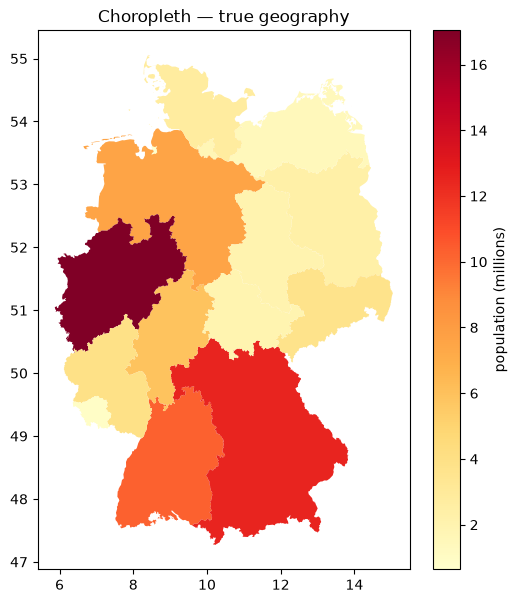

In [4]:
m = Map(crs=4326, figsize=(6, 7))
m.choropleth(states, "population", cmap="YlOrRd")
m.colorbar(label="population (millions)")
m.set_title("Choropleth — true geography")
m.fig;

The signal is there but the page is misallocated: Bavaria and Brandenburg take most of the area, and the dense
city-states are nearly invisible dots. Area is working against the story.

## The cartogram

`scale=` names the column that drives the size. Each polygon shrinks or grows about its centroid, so it stays
roughly where it belongs while its area now encodes the value.

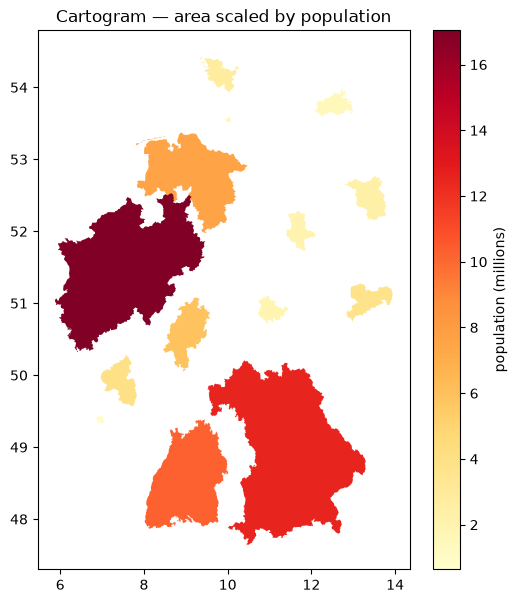

In [5]:
m = Map(crs=4326, figsize=(6, 7))
m.cartogram(states, scale="population", column="population", cmap="YlOrRd")
m.colorbar(label="population (millions)")
m.set_title("Cartogram — area scaled by population")
m.fig;

Now the map reads the way the data does. The populous west — North Rhine-Westphalia, Baden-Württemberg, Bavaria
— swells, while the thinly-peopled north-east shrinks back. Germany's silhouette stays legible enough to orient
by, which is the point of centroid scaling: it distorts area without moving regions away from where a reader
expects to find them.

Note `scale=` and `column=` are separate arguments. Passing both, as here, is the clearest form — size and colour
reinforce one variable. Pass different columns to encode two at once.

## Controlling the distortion with `limits`

`limits` is the `(min, max)` scale factor the values map onto. The default `(0.2, 1.0)` shrinks the smallest to a
fifth of true size and leaves the largest alone.

| argument | meaning | typical value |
|---|---|---|
| `features` | the polygon collection | a polygon `FeatureCollection` |
| `scale` | column driving each polygon's size | a numeric column name |
| `column` | column driving each polygon's colour | often the same column |
| `limits` | `(min, max)` scale factors | `(0.2, 1.0)` default; widen for more contrast |

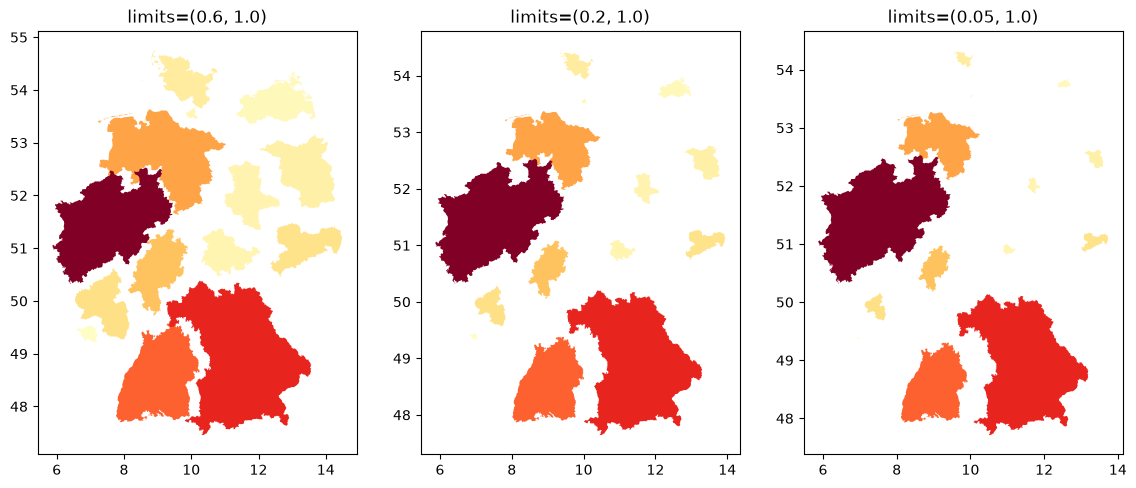

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5.5))
for ax, limits in zip(axes, ((0.6, 1.0), (0.2, 1.0), (0.05, 1.0))):
    panel = Map(ax=ax, crs=4326)
    panel.cartogram(states, scale="population", column="population", cmap="YlOrRd", limits=limits)
    ax.set_title(f"limits={limits}")
fig;

Left: barely distorted — honest about geography, weak about the data. Middle: the default balance. Right: the
sparse east nearly vanishes, which makes the population concentration unmistakable at the cost of a map you can
hardly recognise. Choose with the audience in mind; a cartogram is a rhetorical device as much as a
measurement.

## Takeaway

- A cartogram makes **area carry the value**, fixing the choropleth's bias toward whatever is physically large.
- `scale=` sizes, `column=` colours — the same column to reinforce one variable, different columns for two.
- `limits` tunes how far geography bends: more distortion, more signal, less recognisability.
- Get the per-polygon number from real data — `Dataset.zonal_stats` is pyramids' job, not the plot's.

Next: [`32_lines`](32_lines.ipynb) moves from polygons to line features.